In [33]:
import os
import json
import time
import joblib
from collections import Counter
from itertools import cycle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc

In [34]:
# 🎯 Cargar configuración del modelo MLP desde archivo JSON
json_config_path = r"C:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\mlp_vae_params.json"

with open(json_config_path, "r") as f:
    all_params = json.load(f)

# Seleccionar tipo de dataset VAE: "codigos", "descripciones", "combinado"
dataset_type = "descripciones"  # Cambiar según el dataset que se quiera usar

# Extraer hiperparámetros de configuración
config = all_params[dataset_type]
learning_rate = config["learning_rate"]
batch_size = config["batch_size"]
epochs = config["epochs"]
weight_decay = config["weight_decay"]
hidden_dims = config.get("hidden_dims", [256, 128, 64])  # Arquitectura del MLP
dropout_rate = config.get("dropout_rate", 0.3)

print("🔧 Configuración del MLP cargada desde JSON:")
print(f"Dataset VAE: {dataset_type}")
print(f"Capa Ocultas: {hidden_dims}")
print(f"Dropout Rate: {dropout_rate}")
print(f"Learning Rate: {learning_rate}")
print(f"Batch Size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Weight Decay: {weight_decay}")

🔧 Configuración del MLP cargada desde JSON:
Dataset VAE: descripciones
Capa Ocultas: [256, 128, 64]
Dropout Rate: 0.2
Learning Rate: 2e-05
Batch Size: 16
Epochs: 4
Weight Decay: 0.001


In [35]:
# Configurar dispositivo (GPU / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Definir directorio base de los outputs del VAE
base_dir = r"C:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\dataset_finales\VAE"

# Carga de datasets según la opción seleccionada
if dataset_type == "codigos":
    train_path = os.path.join(base_dir, "codigos_train_VAE.csv")
    test_path = os.path.join(base_dir, "codigos_test_VAE.csv")
elif dataset_type == "descripciones":
    train_path = os.path.join(base_dir, "descripciones_train_VAE.csv")
    test_path = os.path.join(base_dir, "descripciones_test_VAE.csv")
else:  # combinado
    train_path = os.path.join(base_dir, "combinado_train_VAE.csv")
    test_path = os.path.join(base_dir, "combinado_test_VAE.csv")

df_train = pd.read_csv(train_path, sep="|")
df_test = pd.read_csv(test_path, sep="|")

# Filtrar por códigos objetivo
codes = sorted(["F20", "F21", "F22", "F23", "F25", "F29", "F60.1"])
df_train = df_train[df_train["DIAG PSQ"].isin(codes)].copy()
df_test = df_test[df_test["DIAG PSQ"].isin(codes)].copy()

target_col = "DIAG PSQ"
columnas_basura = [target_col, "id", "text", "Unnamed: 0", "label", "Origen"]
feature_cols = [col for col in df_train.columns if col not in columnas_basura]


X_train = df_train[feature_cols].values
X_test = df_test[feature_cols].values

# Codificar etiquetas de forma segura (garantiza que train y test tengan la misma correspondencia)
cat_type = pd.CategoricalDtype(categories=codes, ordered=True)
y_train = df_train[target_col].astype(cat_type).cat.codes.values
y_test = df_test[target_col].astype(cat_type).cat.codes.values

num_classes = len(codes)
input_dim = X_train.shape[1]

print(f"Dimensión de características de entrada: {input_dim}")
print(f"Número de clases: {num_classes}")

# Fijar semilla aleatoria basada en tiempo para PyTorch/Numpy
seed = int(time.time_ns() % (2**32))
torch.manual_seed(seed)
np.random.seed(seed)

# Escalado de datos (Ajustar SOLO con Train, y transformar Train y Test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a Tensores de PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Crear DataLoaders de PyTorch
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("\n📊 Distribución de datos:")
print("Entrenamiento:", Counter(y_train))
print("Evaluación:", Counter(y_test))
print(f"Total ejemplos procesados: {len(df_train) + len(df_test)}")

Usando dispositivo: cuda
Dimensión de características de entrada: 768
Número de clases: 7

📊 Distribución de datos:
Entrenamiento: Counter({np.int8(0): 400, np.int8(2): 291, np.int8(5): 160, np.int8(4): 118, np.int8(3): 75, np.int8(6): 30, np.int8(1): 18})
Evaluación: Counter({np.int8(0): 100, np.int8(2): 54, np.int8(5): 30, np.int8(4): 22, np.int8(3): 14, np.int8(6): 3, np.int8(1): 1})
Total ejemplos procesados: 1316


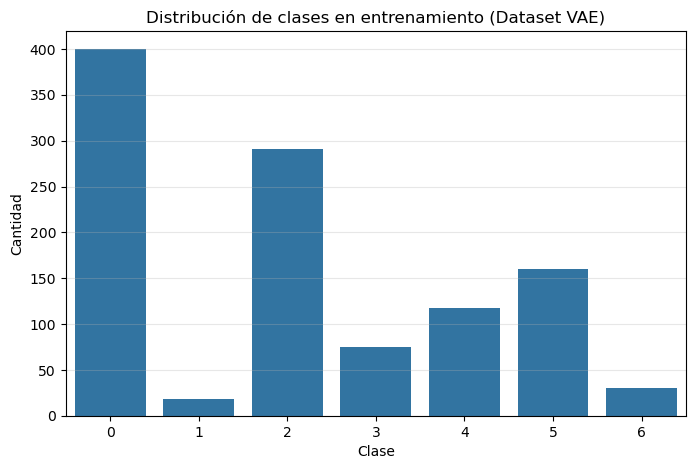

In [36]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title("Distribución de clases en entrenamiento (Dataset VAE)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [37]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout_rate=0.2):
        super(MLPClassifier, self).__init__()
        layers = []
        in_dim = input_dim
        
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim
            
        layers.append(nn.Linear(in_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def calculate_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0)
    }

In [38]:
print(f"\n🚀 Iniciando entrenamiento del MLP para VAE ({dataset_type})")

model = MLPClassifier(input_dim, hidden_dims, num_classes, dropout_rate).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

best_f1 = 0.0
best_model_weights = None

for epoch in range(1, epochs + 1):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_x.size(0)
        
    train_loss /= len(train_loader.dataset)

    # --- FASE DE EVALUACIÓN ---
    model.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            val_preds.extend(preds)
            val_targets.extend(batch_y.numpy())

    epoch_metrics = calculate_metrics(val_targets, val_preds)
    
    # Guardar los mejores pesos basados en F1-Score
    if epoch_metrics['f1'] > best_f1:
        best_f1 = epoch_metrics['f1']
        best_model_weights = model.state_dict().copy()

    if epoch % 10 == 0 or epoch == epochs:
        print(f"Epoch {epoch:03d}/{epochs:03d} | Train Loss: {train_loss:.4f} | Val F1: {epoch_metrics['f1']:.4f} | Val Acc: {epoch_metrics['accuracy']:.4f}")

# Cargar los mejores pesos guardados
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)


🚀 Iniciando entrenamiento del MLP para VAE (descripciones)
Epoch 004/004 | Train Loss: 1.8725 | Val F1: 0.3074 | Val Acc: 0.2946


In [39]:
print("\n📊 Evaluando el mejor modelo...")

model.eval()
final_preds, final_targets = [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        final_preds.extend(preds)
        final_targets.extend(batch_y.numpy())

metrics = calculate_metrics(final_targets, final_preds)

print("\n🏆 Resultados finales:")
print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"F1-Score:  {metrics['f1']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")

# Estructura de resultado
resultado_final = {
    "modelo": "MLP_Classifier",
    "dataset": dataset_type,
    "input_dim": input_dim,
    "hidden_dims": hidden_dims,
    "dropout_rate": dropout_rate,
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "weight_decay": weight_decay,
    "accuracy": metrics['accuracy'],
    "f1": metrics['f1'],
    "precision": metrics['precision'],
    "recall": metrics['recall'],
    "seed": seed
}


📊 Evaluando el mejor modelo...

🏆 Resultados finales:
Accuracy:  0.2946
F1-Score:  0.3074
Precision: 0.4950
Recall:    0.2946



📈 Generando curva ROC...


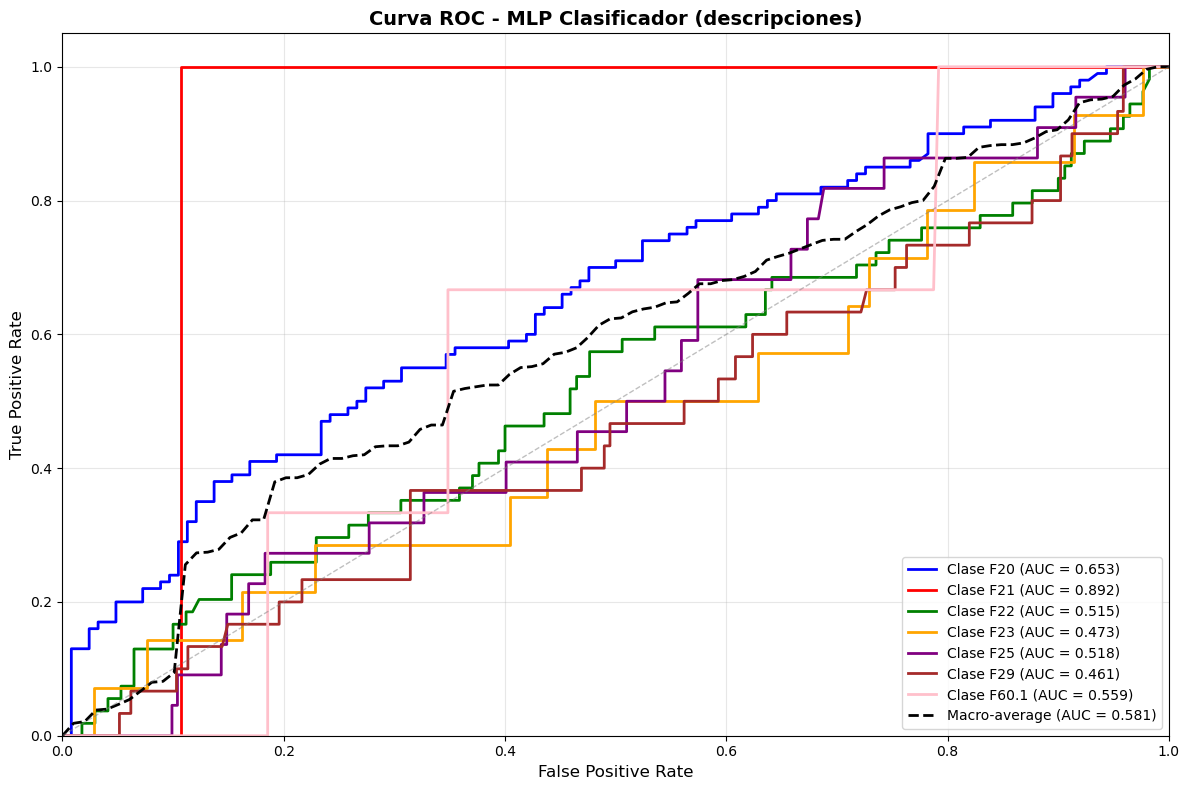

✅ Curva ROC guardada en: ./results/MLP_descripciones\roc_curve.png

📊 AUC Scores por clase:
  Clase F20: 0.6532
  Clase F21: 0.8924
  Clase F22: 0.5149
  Clase F23: 0.4728
  Clase F25: 0.5183
  Clase F29: 0.4612
  Clase F60.1: 0.5588
  Macro-average: 0.5814


In [40]:
print("\n📈 Generando curva ROC...")

# Obtener probabilidades mediante Softmax
model.eval()
all_probs = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)

y_pred_probs = np.vstack(all_probs)
y_test_array = np.array(y_test)

# Binarizar etiquetas reales (One-vs-Rest)
y_test_bin = label_binarize(y_test_array, classes=list(range(num_classes)))

# Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Curva ROC macro-promedio
fpr_macro = np.linspace(0, 1, 100)
tpr_macro = np.zeros_like(fpr_macro)
for i in range(num_classes):
    tpr_macro += np.interp(fpr_macro, fpr[i], tpr[i])
tpr_macro /= num_classes
roc_auc_macro = auc(fpr_macro, tpr_macro)

# Dibujar curvas ROC
plt.figure(figsize=(12, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink'])

for i, color in zip(range(num_classes), colors):
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f'Clase {codes[i]} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot(
    fpr_macro, tpr_macro, 'k--', lw=2,
    label=f'Macro-average (AUC = {roc_auc_macro:.3f})'
)

plt.plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--', alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'Curva ROC - MLP Clasificador ({dataset_type})', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Mostrar y guardar figura
output_dir = f"./results/MLP_{dataset_type}"
os.makedirs(output_dir, exist_ok=True)
roc_plot_path = os.path.join(output_dir, "roc_curve.png")

plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Curva ROC guardada en: {roc_plot_path}")

print("\n📊 AUC Scores por clase:")
for i, code in enumerate(codes):
    print(f"  Clase {code}: {roc_auc[i]:.4f}")
print(f"  Macro-average: {roc_auc_macro:.4f}")

In [41]:
# Definir directorio local de guardado
save_path = f"C:/Users/Usuario/Documents/Workspace/Mirage/models/MLP_{dataset_type}_final"
os.makedirs(save_path, exist_ok=True)

print(f"\n💾 Guardando modelo PyTorch, StandardScaler y resultados en: {save_path}")

# 1. Guardar pesos del modelo (.pt)
torch.save(model.state_dict(), os.path.join(save_path, "mlp_model.pt"))

# 2. Guardar el escalador de datos para inferencia futura
joblib.dump(scaler, os.path.join(save_path, "scaler.joblib"))

# 3. Guardar resultados y hiperparámetros en JSON
config_path = os.path.join(save_path, "training_results.json")
with open(config_path, "w") as f:
    json.dump(resultado_final, f, indent=2)

print("✅ Todo el pipeline del MLP guardado exitosamente!")
print(f"📁 Directorio: {save_path}")

print("\n🎯 RESUMEN FINAL:")
print(f"Modelo: MLP Classifier")
print(f"Dataset VAE: {dataset_type}")
print(f"F1-Score: {metrics['f1']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")


💾 Guardando modelo PyTorch, StandardScaler y resultados en: C:/Users/Usuario/Documents/Workspace/Mirage/models/MLP_descripciones_final
✅ Todo el pipeline del MLP guardado exitosamente!
📁 Directorio: C:/Users/Usuario/Documents/Workspace/Mirage/models/MLP_descripciones_final

🎯 RESUMEN FINAL:
Modelo: MLP Classifier
Dataset VAE: descripciones
F1-Score: 0.3074
Accuracy: 0.2946
